# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import tensorflow as tf

from building_tensorflow.utils import ( 
    TARGET_AUDIO_LEN_TIME,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
)

configure_tf_runtime()
set_global_seed()

paths = get_paths("sincnet_time_tf")
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32
OUT_AUDIO_RS = paths.out_audio_rs

print("Model output:", OUT_TFLITE)

2026-04-15 13:51:51.632382: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 13:51:51.644612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 13:51:51.661323: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 13:51:51.661358: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-15 13:51:51.671445: I tensorflow/core/platform/cpu_feature_gua

Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite


2026-04-15 13:51:54.760386: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 13:51:54.794386: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-15 13:51:54.797685: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print(len(train_ds),len(val_ds),len(test_ds))

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.


2026-04-15 13:51:55.765097: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [4]:
class CustomFrontend(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
        })
        return config

In [ ]:
NUM_FILTERS = 48
NUM_FILTERS_2 = 16
DENSE_HIDDEN = 64
KERNEL_SIZE = 32
KERNEL_SIZE_2 = 16
STRIDE = 8
STRIDE_2 = 8

def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS,
        kernel_size=KERNEL_SIZE,
        stride=STRIDE,
        name="sinc_frontend")(inputs)
    x = tf.keras.layers.AveragePooling1D(
        pool_size=2,
        strides=2,
        padding="valid",
    )(x)
    x = tf.keras.layers.Conv1D(
        filters=NUM_FILTERS_2,
        kernel_size=KERNEL_SIZE_2,
        strides=STRIDE_2,
        padding="valid",
        use_bias=False,
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None)(x)
    return tf.keras.Model(inputs, outputs, name="sincnet_time_multilayer")


training_model = build_training_model(num_labels)
training_model.summary()

Model: "sincnet_time_multilayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 5981, 48)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 2990, 48)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 372, 24)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 372, 24)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,562 (88.13 KB)

 Trainable params: 22,562 (88.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from building_tensorflow.utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb("sincnet_multilayer", config={
    "num_filters": NUM_FILTERS,
    "num_filters_2": NUM_FILTERS_2,
    "kernel_size": KERNEL_SIZE,
    "kernel_size_2": KERNEL_SIZE_2,
    "stride": STRIDE,
    "stride_2": STRIDE_2,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776253918.702190   27768 service.cc:145] XLA service 0x77c1540056c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776253918.702226   27768 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-15 13:51:58.746818: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-15 13:51:58.916706: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 22/353 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6781 - loss: 0.6726

I0000 00:00:1776253921.317101   27768 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.7934 - loss: 0.4121 - val_accuracy: 0.8848 - val_loss: 0.2834
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8673 - loss: 0.2930 - val_accuracy: 0.9188 - val_loss: 0.2263
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8999 - loss: 0.2405 - val_accuracy: 0.9471 - val_loss: 0.1826
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9260 - loss: 0.1985 - val_accuracy: 0.9514 - val_loss: 0.1587
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9309 - loss: 0.1778 - val_accuracy: 0.9457 - val_loss: 0.1544
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9327 - loss: 0.1674 - val_accuracy: 0.9428 - val_loss: 0.1455
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9330 - loss: 0.1624 - val_accuracy: 0.9471 - val_loss: 0.1415
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9358 - loss: 0.1567 - val_

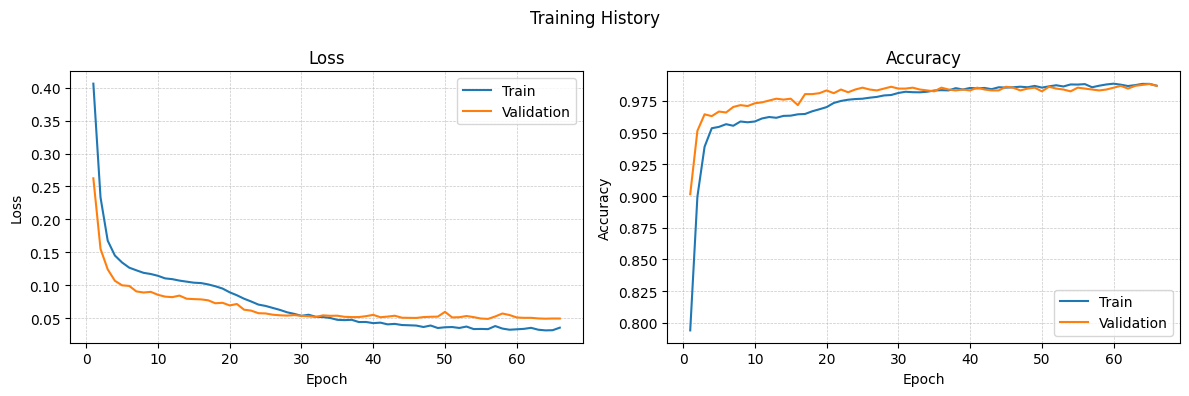

In [ ]:
from building_tensorflow.utils import plot_training_history
plot_training_history(history)

351it [00:17, 22.03it/s]2026-04-15 13:19:37.350703: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
353it [00:17, 20.35it/s]
44it [00:02, 19.75it/s]2026-04-15 13:19:39.640484: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:02, 21.68it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.3607  (best F2 threshold)
Accuracy : 0.9792
Precision: 0.9441
Recall   : 0.9956
F2 score : 0.9849
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9994


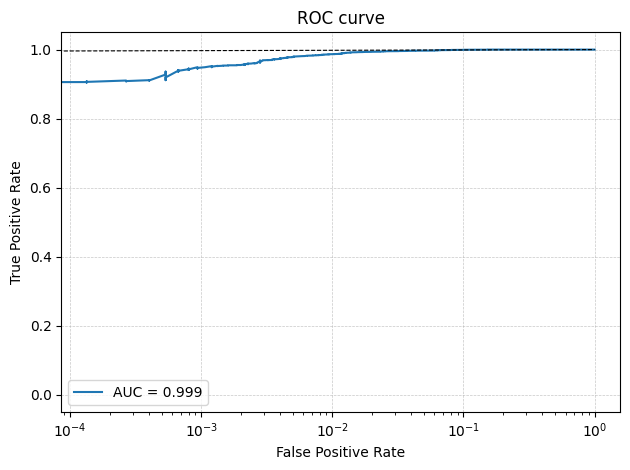

In [ ]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics
train_metrics, test_metrics = evaluate_binary_classifier(training_model,
 train_ds,
 test_ds,
  threshold=0.5,)
display_eval_metrics(train_metrics, test_metrics)